# EDA Notebook for BasyTec data


Purpose of this notebook is to extract general information from any basytec data and show it to the user . 

Information such as , how many cycles are recoreded in the file. How many of them charge, how many discharge, and what are their C-rate (relatvie to the biggest current) and what are the capacity fading throughout the experiment. 
Whether if we can distinguish a CC or CV step in charge or discharge . and if there are OCV steps. 

These information are handy to complement our dataset and make it ready for deeper analysis . 



In [2]:
import sys
import os

# Add src/ to sys.path so you can import batterydata
sys.path.append(os.path.abspath('../src'))

from batterydata.parsers.basytec_reader import BasyTecReader


In [3]:
import yaml

with open('../local_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
file_path = config['basytec_sample_file']


In [4]:
reader = BasyTecReader(filepath=file_path, sample_id="demo")
result = reader.read()
df = result['data']

print(df.head())

    time_s  dataset_idx  step_time_s  set_time_s  line_idx  voltage_v  \
0  0.00000            1      0.00000     0.00000         2   3.832572   
1  0.00338            2      0.00338     0.00338         2   3.826466   
2  1.00237            3      1.00237     1.00237         2   3.820360   
3  2.00182            4      2.00182     2.00182         2   3.818451   
4  3.00259            5      3.00259     3.00259         2   3.816925   

   current_a     charge_ah  step_charge_ah     energy_wh  cycle_index  \
0  -0.000541 -3.552998e-08   -3.552998e-08 -1.361712e-07            1   
1  -1.298575 -1.254026e-06   -1.254026e-06 -4.798706e-06            1   
2  -1.299990 -3.620021e-04   -3.620021e-04 -1.383510e-03            1   
3  -1.300017 -7.229127e-04   -7.229127e-04 -2.761937e-03            1   
4  -1.299999 -1.084302e-03   -1.084302e-03 -4.141601e-03            1   

   state_code  
0           3  
1           0  
2           1  
3           1  
4           1  


In [4]:
df

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code
0,0.000000e+00,1,0.00000,0.000000e+00,2,3.832572,-0.000541,-3.552998e-08,-3.552998e-08,-1.361712e-07,1,3
1,3.380000e-03,2,0.00338,3.380000e-03,2,3.826466,-1.298575,-1.254026e-06,-1.254026e-06,-4.798706e-06,1,0
2,1.002370e+00,3,1.00237,1.002370e+00,2,3.820360,-1.299990,-3.620021e-04,-3.620021e-04,-1.383510e-03,1,1
3,2.001820e+00,4,2.00182,2.001820e+00,2,3.818451,-1.300017,-7.229127e-04,-7.229127e-04,-2.761937e-03,1,1
4,3.002590e+00,5,3.00259,3.002590e+00,2,3.816925,-1.299999,-1.084302e-03,-1.084302e-03,-4.141601e-03,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2991357,2.987259e+06,2991360,1368.00278,2.987259e+06,8,3.850127,-1.299999,1.066213e-01,-4.939803e-01,3.236559e+01,196,1
2991358,2.987260e+06,2991361,1369.00282,2.987260e+06,8,3.849746,-1.299990,1.062601e-01,-4.943414e-01,3.236420e+01,196,1
2991359,2.987261e+06,2991362,1370.00291,2.987261e+06,8,3.849746,-1.300008,1.058990e-01,-4.947026e-01,3.236281e+01,196,1
2991360,2.987262e+06,2991363,1371.00264,2.987262e+06,8,3.849555,-1.299999,1.055380e-01,-4.950636e-01,3.236142e+01,196,1


In [5]:
n_cycles = df['cycle_index'].nunique()
print(f"Number of cycles detected: {n_cycles}")


Number of cycles detected: 201


## Segmentation of each step 

we need to segment each part of the time series to see if it belongs to a charging step, dischargin step or OCV step . also, number of occurence of each step is important. 




In [5]:
import numpy as np

# Define logic for step type (tune as needed for your experiment!)
def classify_row(row):
    if abs(row['current_a']) < 0.001:  # this  threshold should be adjusted. 
        return "OCV"
    elif row['current_a'] > 0:
        return "charge"
    elif row['current_a'] < 0:
        return "discharge"
    else:
        return "unknown"

df['step_type'] = df.apply(classify_row, axis=1)

# Identify where step type changes (i.e., start of a new step)
step_change = df['step_type'] != df['step_type'].shift(1)
df['step_number'] = step_change.cumsum()




In [7]:
df

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code,step_type,step_number
0,0.000000e+00,1,0.00000,0.000000e+00,2,3.832572,-0.000541,-3.552998e-08,-3.552998e-08,-1.361712e-07,1,3,OCV,1
1,3.380000e-03,2,0.00338,3.380000e-03,2,3.826466,-1.298575,-1.254026e-06,-1.254026e-06,-4.798706e-06,1,0,discharge,2
2,1.002370e+00,3,1.00237,1.002370e+00,2,3.820360,-1.299990,-3.620021e-04,-3.620021e-04,-1.383510e-03,1,1,discharge,2
3,2.001820e+00,4,2.00182,2.001820e+00,2,3.818451,-1.300017,-7.229127e-04,-7.229127e-04,-2.761937e-03,1,1,discharge,2
4,3.002590e+00,5,3.00259,3.002590e+00,2,3.816925,-1.299999,-1.084302e-03,-1.084302e-03,-4.141601e-03,1,1,discharge,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991357,2.987259e+06,2991360,1368.00278,2.987259e+06,8,3.850127,-1.299999,1.066213e-01,-4.939803e-01,3.236559e+01,196,1,discharge,1999
2991358,2.987260e+06,2991361,1369.00282,2.987260e+06,8,3.849746,-1.299990,1.062601e-01,-4.943414e-01,3.236420e+01,196,1,discharge,1999
2991359,2.987261e+06,2991362,1370.00291,2.987261e+06,8,3.849746,-1.300008,1.058990e-01,-4.947026e-01,3.236281e+01,196,1,discharge,1999
2991360,2.987262e+06,2991363,1371.00264,2.987262e+06,8,3.849555,-1.299999,1.055380e-01,-4.950636e-01,3.236142e+01,196,1,discharge,1999


In [ ]:
# segmentation of CC CV OCV , and step duration . 
# this is needed to then draw diagram of the experiment DoE based on the experiment 
# and also start analyzing the data 

In [72]:
def segment_cc_cv_threshold(df, current_col='current_a', voltage_col='voltage_v', step_col='step_number'):
    epsilon = 0.001  # voltage threshold (V)
    current_thr = 0.01  # OCV threshold (A)

    df['cc_cv'] = None

    for step, group in df.groupby(step_col):
        idx = group.index
        current = group[current_col]
        voltage = group[voltage_col]
        # 1. OCV
        if current.abs().mean() < current_thr:
            df.loc[idx, 'cc_cv'] = 'OCV'
        # 2. Charge (mean current > 0)
        elif current.mean() > 0:
            v_max = voltage.max()
            # CV starts when voltage reaches max (within epsilon)
            cv_start = idx[(voltage >= v_max - epsilon)][0]
            df.loc[idx[idx < cv_start], 'cc_cv'] = 'CC'
            df.loc[idx[idx >= cv_start], 'cc_cv'] = 'CV'
        # 3. Discharge (mean current < 0)
        elif current.mean() < 0:
            v_min = voltage.min()
            cv_start = idx[(voltage <= v_min + epsilon)][0]
            df.loc[idx[idx < cv_start], 'cc_cv'] = 'CC'
            df.loc[idx[idx >= cv_start], 'cc_cv'] = 'CV'
        else:
            df.loc[idx, 'cc_cv'] = 'Other'
    return df


In [ ]:
df_threshold = segment_cc_cv_threshold(df)


In [52]:
#  check segmentation . does it work  ? 

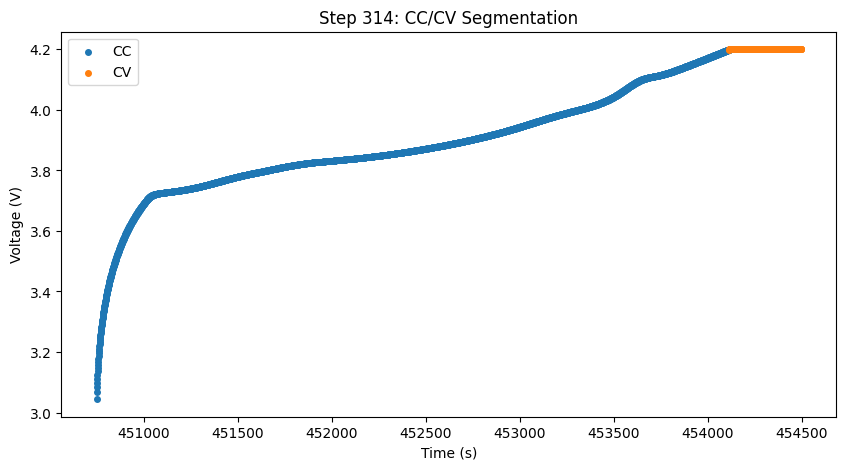

In [74]:
import matplotlib.pyplot as plt

def plot_cc_cv(df, step_number, time_col='time_s', voltage_col='voltage_v', current_col='current_a', cc_cv_col='cc_cv'):
    step_df = df[df['step_number'] == step_number].copy()
    if step_df.empty:
        print(f"No data for step {step_number}")
        return
    
    # Assign a color for each segment type
    colors = {'CC': 'tab:blue', 'CV': 'tab:orange', 'OCV': 'tab:green', 'Other': 'gray'}
    unique_labels = step_df[cc_cv_col].unique()
    
    plt.figure(figsize=(10,5))
    for label in unique_labels:
        sub = step_df[step_df[cc_cv_col] == label]
        plt.scatter(sub[time_col], sub[voltage_col], label=label, color=colors.get(label, 'gray'), s=16)
    
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.title(f"Step {step_number}: CC/CV Segmentation")
    plt.legend()
    plt.show()

plot_cc_cv(df, step_number=314)


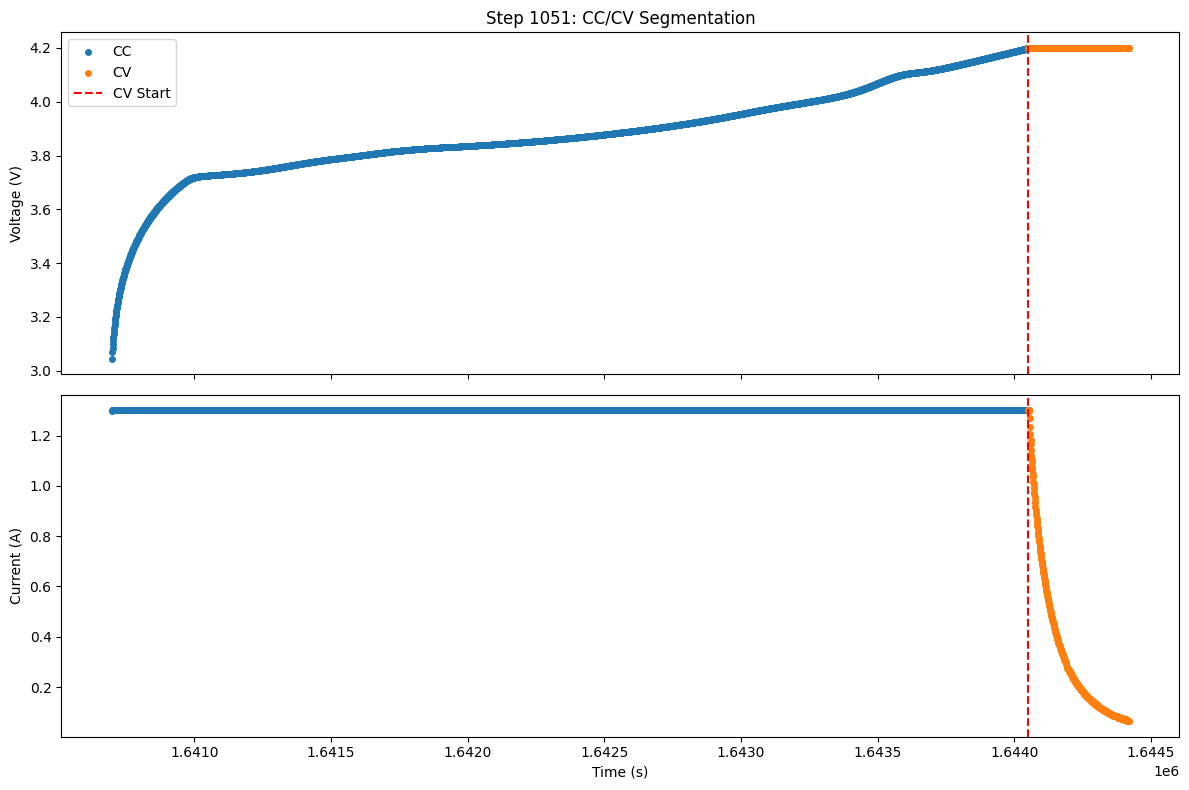

In [75]:
import matplotlib.pyplot as plt

def plot_cc_cv_with_current(df, step_number, time_col='time_s', voltage_col='voltage_v', current_col='current_a', cc_cv_col='cc_cv'):
    step_df = df[df['step_number'] == step_number].copy()
    if step_df.empty:
        print(f"No data for step {step_number}")
        return

    colors = {'CC': 'tab:blue', 'CV': 'tab:orange', 'OCV': 'tab:green', 'Other': 'gray'}
    unique_labels = step_df[cc_cv_col].unique()

    # Find the index (relative to step_df) where CV starts
    cv_start_idx = step_df.index[step_df[cc_cv_col] == 'CV']
    if not cv_start_idx.empty:
        cv_start = step_df.loc[cv_start_idx[0], time_col]
    else:
        cv_start = None

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

    # Voltage plot
    for label in unique_labels:
        sub = step_df[step_df[cc_cv_col] == label]
        ax1.scatter(sub[time_col], sub[voltage_col], label=label, color=colors.get(label, 'gray'), s=16)
    if cv_start is not None:
        ax1.axvline(cv_start, color='red', linestyle='--', label='CV Start')
    ax1.set_ylabel('Voltage (V)')
    ax1.set_title(f"Step {step_number}: CC/CV Segmentation")
    ax1.legend()

    # Current plot
    for label in unique_labels:
        sub = step_df[step_df[cc_cv_col] == label]
        ax2.scatter(sub[time_col], sub[current_col], label=label, color=colors.get(label, 'gray'), s=16)
    if cv_start is not None:
        ax2.axvline(cv_start, color='red', linestyle='--', label='CV Start')
    ax2.set_ylabel('Current (A)')
    ax2.set_xlabel('Time (s)')

    plt.tight_layout()
    plt.show()

# Example usage:
plot_cc_cv_with_current(df, step_number=1051)


In [ ]:
df

In [78]:
n = 1051
print(df[(df.step_number == n ) & (df.cc_cv == "CC")]["current_a"].median()/1.3)
print(df[(df.step_number == n ) & (df.cc_cv == "CC")]["current_a"].mean()/1.3)

0.9999990131171999
0.999999623454


In [79]:
import pandas as pd
import numpy as np

# This will hold a summary row for each segment
step_summaries = []

for step_no, step_df in df.groupby('step_number'):
    step_type = step_df['step_type'].iloc[0]
    start_time = step_df['time_s'].iloc[0]
    end_time = step_df['time_s'].iloc[-1]
    duration = end_time - start_time

    # Defaults
    param_dict = {
        'step_number': step_no,
        'step_type': step_type,
        'start_time': start_time,
        'end_time': end_time,
        'duration_s': duration
    }

    if step_type == 'OCV':
        param_dict['mean_voltage'] = step_df['voltage_v'].mean()
        param_dict['mean_current'] = step_df['current_a'].mean()

    elif step_type == 'charge':
        # CC region
        cc_mask = step_df['cc_cv'] == 'CC'
        if cc_mask.any():
            param_dict['charge_cc_current'] = step_df.loc[cc_mask, 'current_a'].mean()
            param_dict['charge_cc_duration'] = step_df.loc[cc_mask, 'time_s'].iloc[-1] - step_df.loc[cc_mask, 'time_s'].iloc[0]
            param_dict['charge_cc_cutoff_voltage'] = step_df.loc[cc_mask, 'voltage_v'].max()
        # CV region
        cv_mask = step_df['cc_cv'] == 'CV'
        if cv_mask.any():
            param_dict['charge_cv_voltage'] = step_df.loc[cv_mask, 'voltage_v'].mean()
            param_dict['charge_cv_duration'] = step_df.loc[cv_mask, 'time_s'].iloc[-1] - step_df.loc[cv_mask, 'time_s'].iloc[0]
            param_dict['charge_cv_cutoff_current'] = step_df.loc[cv_mask, 'current_a'].abs().min()
    
    elif step_type == 'discharge':
        cc_mask = step_df['cc_cv'] == 'CC'
        if cc_mask.any():
            param_dict['discharge_cc_current'] = step_df.loc[cc_mask, 'current_a'].mean()
            param_dict['discharge_cc_duration'] = step_df.loc[cc_mask, 'time_s'].iloc[-1] - step_df.loc[cc_mask, 'time_s'].iloc[0]
            param_dict['discharge_cc_cutoff_voltage'] = step_df.loc[cc_mask, 'voltage_v'].min()
        cv_mask = step_df['cc_cv'] == 'CV'
        if cv_mask.any():
            param_dict['discharge_cv_voltage'] = step_df.loc[cv_mask, 'voltage_v'].mean()
            param_dict['discharge_cv_duration'] = step_df.loc[cv_mask, 'time_s'].iloc[-1] - step_df.loc[cv_mask, 'time_s'].iloc[0]
            param_dict['discharge_cv_cutoff_current'] = step_df.loc[cv_mask, 'current_a'].abs().min()

    # You can add more custom fields if needed

    step_summaries.append(param_dict)

# Create DataFrame
steps_df = pd.DataFrame(step_summaries)


In [ ]:
steps_df

In [80]:
# clean and throw out those steps with less than critical duration (here 0.5 second) they are just noise from machine 
steps_df_clean = steps_df[steps_df['duration_s'] > 0.5].reset_index(drop=True)


In [81]:
cell_capacity_ah = 1.3  # Or user input

def get_c_rate(current, cap=cell_capacity_ah):
    return current / cap if cap else None

steps_df_clean['c_rate'] = None

for i, row in steps_df_clean.iterrows():
    if row['step_type'] == 'charge' and not pd.isna(row.get('charge_cc_current', None)):
        steps_df_clean.at[i, 'c_rate'] = get_c_rate(row['charge_cc_current'])
    elif row['step_type'] == 'discharge' and not pd.isna(row.get('discharge_cc_current', None)):
        steps_df_clean.at[i, 'c_rate'] = get_c_rate(abs(row['discharge_cc_current']))


In [82]:
steps_df_clean

,step_number,step_type,start_time,end_time,duration_s,mean_voltage,mean_current,discharge_cc_current,discharge_cc_duration,discharge_cc_cutoff_voltage,discharge_cv_voltage,discharge_cv_duration,discharge_cv_cutoff_current,charge_cc_current,charge_cc_duration,charge_cc_cutoff_voltage,charge_cv_voltage,charge_cv_duration,charge_cv_cutoff_current,c_rate
0,2,discharge,3.380000e-03,1.718260e+03,1718.25642,NaN,NaN,-1.300001,1716.99938,3.002706,2.999526,0.25630,0.708756,NaN,NaN,NaN,NaN,NaN,NaN,1.000001
1,3,OCV,1.718373e+03,2.318606e+03,600.23244,3.130501,-8.965060e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,4,charge,2.318610e+03,6.055263e+03,3736.65335,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.300000,3362.99942,4.199133,4.200084,372.65387,0.060864,1.0
3,5,OCV,6.055376e+03,6.065608e+03,10.23258,4.199397,-9.132982e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,7,discharge,6.066612e+03,9.531772e+03,3465.15985,NaN,NaN,-1.300000,3464.00104,3.001752,2.999462,0.15859,0.704260,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1587,1994,discharge,2.978738e+06,2.982169e+06,3430.57299,NaN,NaN,-1.300000,3429.00030,3.006713,2.999653,0.57272,0.686410,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1588,1995,OCV,2.982169e+06,2.982179e+06,10.23822,3.026412,-4.158408e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1589,1996,charge,2.982179e+06,2.985881e+06,3701.22430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.299999,3336.99844,4.198751,4.200079,363.22615,0.063589,0.999999
1590,1997,OCV,2.985881e+06,2.985891e+06,10.22892,4.199485,-6.393087e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [83]:
def step_signature(row):
    # OCV: Only duration matters
    if row['step_type'] == 'OCV':
        return f"OCV_{int(row['duration_s'])}"
    elif row['step_type'] == 'charge':
        # Use cutoff voltage, c_rate, and cc_cv split
        cv = f"{row.get('charge_cc_cutoff_voltage', np.nan):.1f}"
        cr = f"{row.get('c_rate', np.nan):.2f}"
        has_cv = 'CV' if not pd.isna(row.get('charge_cv_duration')) else 'noCV'
        return f"CH_{cr}_V{cv}_{has_cv}"
    elif row['step_type'] == 'discharge':
        cv = f"{row.get('discharge_cc_cutoff_voltage', np.nan):.1f}"
        cr = f"{row.get('c_rate', np.nan):.2f}"
        has_cv = 'CV' if not pd.isna(row.get('discharge_cv_duration')) else 'noCV'
        return f"DIS_{cr}_V{cv}_{has_cv}"
    else:
        return row['step_type']


In [84]:
steps_df_clean['step_sig'] = steps_df_clean.apply(step_signature, axis=1)


In [85]:
protocol = list(steps_df_clean['step_sig'])
print(protocol)


['DIS_1.00_V3.0_CV', 'OCV_600', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_

In [88]:
def detect_repeating_blocks_v2(seq, min_block_len=2, max_block_len=10, min_repeats=2, max_mismatches=0):
    i = 0
    n = len(seq)
    summary = []
    while i < n:
        best = None
        # Try all possible block lengths from longest to shortest
        for blen in range(max_block_len, min_block_len-1, -1):
            if i + blen * min_repeats > n:
                continue
            block = seq[i:i+blen]
            reps = 1
            cur = i + blen
            while cur + blen <= n and sum([block[j] != seq[cur+j] for j in range(blen)]) <= max_mismatches:
                reps += 1
                cur += blen
            if reps >= min_repeats:
                best = (blen, reps, block)
                break  # break on longest found
        if best:
            blen, reps, block = best
            summary.append({'block': block, 'count': reps, 'start': i})
            i += reps * blen
        else:
            summary.append({'block': [seq[i]], 'count': 1, 'start': i})
            i += 1
    return summary

# --- Usage Example ---

seq = [
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_0.92_V4.2_CV', 'OCV_10',
    'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10'
]

summary = detect_repeating_blocks_v2(protocol, min_block_len=4, max_block_len=4, min_repeats=2, max_mismatches=0)
for s in summary:
    if s['count'] > 1:
        print(f"{s['count']} x ({', '.join(s['block'])})")
    else:
        print(', '.join(s['block']))



DIS_1.00_V3.0_CV
OCV_600
200 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
DIS_1.00_V3.0_CV
OCV_10
CH_0.05_V4.2_CV
OCV_10
DIS_0.05_V3.0_CV
160 x (OCV_10, CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV)
OCV_10
CH_1.00_V3.8_CV
35 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
CH_1.00_V4.2_CV
OCV_10
DIS_1.00_V3.9_CV


In [89]:
def detect_repeating_blocks_with_steps(
    seq, min_block_len=2, max_block_len=10, min_repeats=2, max_mismatches=0
):
    i = 0
    n = len(seq)
    summary = []
    while i < n:
        best = None
        for blen in range(max_block_len, min_block_len - 1, -1):
            if i + blen * min_repeats > n:
                continue
            block = seq[i : i + blen]
            reps = 1
            cur = i + blen
            while (
                cur + blen <= n
                and sum([block[j] != seq[cur + j] for j in range(blen)]) <= max_mismatches
            ):
                reps += 1
                cur += blen
            if reps >= min_repeats:
                best = (blen, reps, block)
                break
        if best:
            blen, reps, block = best
            summary.append({'block': block, 'count': reps, 'start': i})
            i += reps * blen
        else:
            summary.append({'block': [seq[i]], 'count': 1, 'start': i})
            i += 1
    return summary

# --- Usage Example ---

seq = [
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10',
    'CH_0.92_V4.2_CV', 'OCV_10',
    'DIS_1.00_V3.0_CV', 'OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10'
]

summary = detect_repeating_blocks_with_steps(
    protocol, min_block_len=4, max_block_len=4, min_repeats=2, max_mismatches=0
)
for s in summary:
    step = s['start']
    if s['count'] > 1:
        print(f"Step {step}: {s['count']} x ({', '.join(s['block'])})")
    else:
        print(f"Step {step}: {', '.join(s['block'])}")


Step 0: DIS_1.00_V3.0_CV
Step 1: OCV_600
Step 2: 200 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
Step 802: DIS_1.00_V3.0_CV
Step 803: OCV_10
Step 804: CH_0.05_V4.2_CV
Step 805: OCV_10
Step 806: DIS_0.05_V3.0_CV
Step 807: 160 x (OCV_10, CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV)
Step 1447: OCV_10
Step 1448: CH_1.00_V3.8_CV
Step 1449: 35 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
Step 1589: CH_1.00_V4.2_CV
Step 1590: OCV_10
Step 1591: DIS_1.00_V3.9_CV


In [99]:

blocks = detect_repeating_blocks_with_steps(protocol, min_block_len=4, max_block_len=4, min_repeats=2, max_mismatches=0)


In [100]:
for s in blocks:
    step = s['start']
    if s['count'] > 1:
        print(f"Step {step}: {s['count']} x ({', '.join(s['block'])})")
    else:
        print(f"Step {step}: {', '.join(s['block'])}")


Step 0: DIS_1.00_V3.0_CV
Step 1: OCV_600
Step 2: 200 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
Step 802: DIS_1.00_V3.0_CV
Step 803: OCV_10
Step 804: CH_0.05_V4.2_CV
Step 805: OCV_10
Step 806: DIS_0.05_V3.0_CV
Step 807: 160 x (OCV_10, CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV)
Step 1447: OCV_10
Step 1448: CH_1.00_V3.8_CV
Step 1449: 35 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_CV, OCV_10)
Step 1589: CH_1.00_V4.2_CV
Step 1590: OCV_10
Step 1591: DIS_1.00_V3.9_CV


In [107]:
print (blocks)

[{'block': ['DIS_1.00_V3.0_CV'], 'count': 1, 'start': 0}, {'block': ['OCV_600'], 'count': 1, 'start': 1}, {'block': ['CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10'], 'count': 200, 'start': 2}, {'block': ['DIS_1.00_V3.0_CV'], 'count': 1, 'start': 802}, {'block': ['OCV_10'], 'count': 1, 'start': 803}, {'block': ['CH_0.05_V4.2_CV'], 'count': 1, 'start': 804}, {'block': ['OCV_10'], 'count': 1, 'start': 805}, {'block': ['DIS_0.05_V3.0_CV'], 'count': 1, 'start': 806}, {'block': ['OCV_10', 'CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV'], 'count': 160, 'start': 807}, {'block': ['OCV_10'], 'count': 1, 'start': 1447}, {'block': ['CH_1.00_V3.8_CV'], 'count': 1, 'start': 1448}, {'block': ['CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_CV', 'OCV_10'], 'count': 35, 'start': 1449}, {'block': ['CH_1.00_V4.2_CV'], 'count': 1, 'start': 1589}, {'block': ['OCV_10'], 'count': 1, 'start': 1590}, {'block': ['DIS_1.00_V3.9_CV'], 'count': 1, 'start': 1591}]


In [109]:
import numpy as np

steps_df_clean['block_id'] = np.nan
steps_df_clean['cycle_number'] = np.nan

for block_idx, block_info in enumerate(blocks):
    block = block_info['block']
    count = block_info['count']
    start = block_info['start']
    block_len = len(block)
    for repeat in range(count):
        # Calculate start and end indices for this block repeat in steps_df_clean
        idx_start = start + repeat * block_len
        idx_end = idx_start + block_len
        steps_df_clean.loc[idx_start:idx_end-1, 'block_id'] = block_idx
        steps_df_clean.loc[idx_start:idx_end-1, 'cycle_number'] = repeat + 1  # 1-based count

steps_df_clean['block_id'] = steps_df_clean['block_id'].astype(int)
steps_df_clean['cycle_number'] = steps_df_clean['cycle_number'].astype(int)


In [ ]:
steps_df_clean

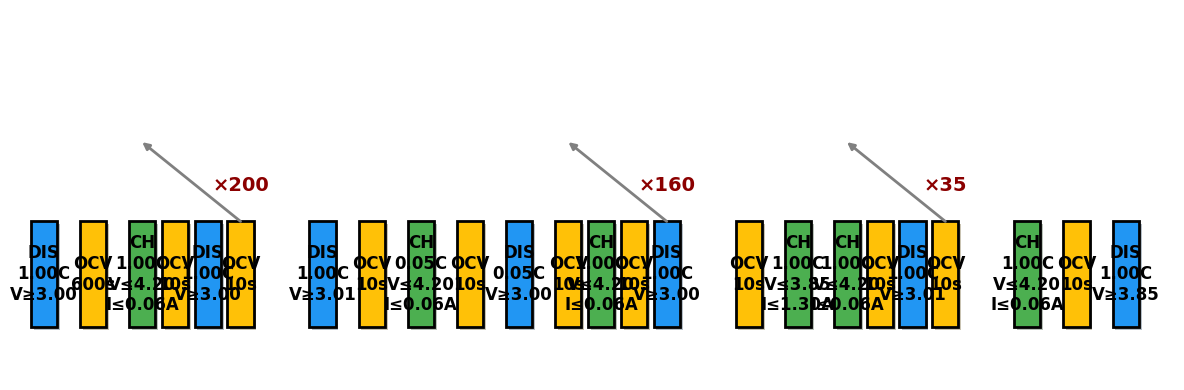

In [110]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
import matplotlib.patheffects as pe

# Assign colors to each step type
STEP_COLORS = {
    'charge': '#4CAF50',    # green
    'discharge': '#2196F3', # blue
    'OCV': '#FFC107',       # yellow
    'other': '#E0E0E0',     # gray
}

def step_label(row):
    if row['step_type'] == 'OCV':
        return f"OCV\n{int(row['duration_s'])}s"
    elif row['step_type'] == 'charge':
        txt = f"CH\n{row['c_rate']:.2f}C\nV≤{row['charge_cc_cutoff_voltage']:.2f}"
        if not pd.isna(row.get('charge_cv_cutoff_current')):
            txt += f"\nI≤{row['charge_cv_cutoff_current']:.2f}A"
        return txt
    elif row['step_type'] == 'discharge':
        txt = f"DIS\n{row['c_rate']:.2f}C\nV≥{row['discharge_cc_cutoff_voltage']:.2f}"
        return txt
    else:
        return row['step_type']

def draw_protocol(blocks, steps_df_clean):
    fig, ax = plt.subplots(figsize=(12, 4))
    x = 0
    y = 0
    box_width = 2
    box_height = 2
    padding = 0.5

    for block_idx, block_info in enumerate(blocks):
        block = block_info['block']
        count = block_info['count']
        start = block_info['start']
        block_len = len(block)
        block_steps = steps_df_clean.iloc[start:start+block_len]
        block_boxes = []

        # Draw steps of the block
        for i, (idx, row) in enumerate(block_steps.iterrows()):
            color = STEP_COLORS.get(row['step_type'], STEP_COLORS['other'])
            label = step_label(row)
            # Draw rectangle
            rect = Rectangle((x, y), box_width, box_height, facecolor=color,
                             edgecolor='k', lw=2, zorder=2,
                             path_effects=[pe.withSimplePatchShadow()])
            ax.add_patch(rect)
            ax.text(x + box_width/2, y + box_height/2, label,
                    ha='center', va='center', fontsize=12, fontweight='bold')
            block_boxes.append((x, y))
            x += box_width + padding

        # If this block repeats (count > 1), draw loop and label
        if count > 1:
            start_xy = block_boxes[0]
            end_xy = block_boxes[-1]
            # Draw an arrow from end to start above the boxes
            arrow_x = (end_xy[0] + box_width/2, start_xy[0] + box_width/2)
            arrow_y = (end_xy[1] + box_height, start_xy[1] + box_height + 1.5)
            ax.annotate("",
                        xy=(arrow_x[1], arrow_y[1]),
                        xytext=(arrow_x[0], arrow_y[0]),
                        arrowprops=dict(arrowstyle="-|>", lw=2, color='gray', shrinkA=0, shrinkB=0),
                        annotation_clip=False)
            # Write number of cycles under arrow (just above boxes)
            ax.text(arrow_x[0], arrow_y[0] + 0.5, f"×{count}", ha='center', va='bottom',
                    fontsize=14, fontweight='bold', color='darkred', zorder=10)

        # Move to next block's x position, with extra space if block repeats
        x += (box_width + padding) * (0.5 if count == 1 else 1.5)

    ax.set_xlim(-1, x+1)
    ax.set_ylim(-1, box_height + 4)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
draw_protocol(blocks, steps_df_clean)


In [113]:
!pip install graphviz

In [118]:
from graphviz import Digraph

def protocol_flow_graphviz(blocks, steps_df_clean, filename='protocol_flowchart'):
    # Helper to create nice node labels
    def step_label(row):
        if row['step_type'] == 'OCV':
            return f"OCV\\n{int(row['duration_s'])}s"
        elif row['step_type'] == 'charge':
            label = f"CHARGE"
            if 'c_rate' in row and not pd.isna(row['c_rate']):
                label += f"\\n{row['c_rate']:.2f}C"
            if 'charge_cc_cutoff_voltage' in row and not pd.isna(row['charge_cc_cutoff_voltage']):
                label += f"\\nVcut {row['charge_cc_cutoff_voltage']:.2f}V"
            if 'charge_cv_cutoff_current' in row and not pd.isna(row['charge_cv_cutoff_current']):
                label += f"\\nCVcut {row['charge_cv_cutoff_current']:.2f}A"
            return label
        elif row['step_type'] == 'discharge':
            label = f"DISCH"
            if 'c_rate' in row and not pd.isna(row['c_rate']):
                label += f"\\n{row['c_rate']:.2f}C"
            if 'discharge_cc_cutoff_voltage' in row and not pd.isna(row['discharge_cc_cutoff_voltage']):
                label += f"\\nVcut {row['discharge_cc_cutoff_voltage']:.2f}V"
            return label
        else:
            return row['step_type']

    # Colors for each step type
    type_color = {
        'OCV': 'gold',
        'charge': 'lightgreen',
        'discharge': 'lightblue',
        'Other': 'gray'
    }
    dot = Digraph(comment='Battery DoE Protocol', format='png')
    dot.attr(rankdir='TB', nodesep='0.7', ranksep='1')


    # Track nodes and their IDs for edges
    block_node_ids = []
    for block_idx, block_info in enumerate(blocks):
        block = block_info['block']
        count = block_info['count']
        start = block_info['start']
        block_len = len(block)
        block_steps = steps_df_clean.iloc[start:start+block_len]

        prev_node_id = None
        block_node_ids.append([])

        # For each step in block, create a node
        for i, (step_i, row) in enumerate(block_steps.iterrows()):
            # Unique node id: block_idx_step
            node_id = f"b{block_idx}_s{i}"
            label = step_label(row)
            # Set color by step_type
            step_type = row['step_type'] if row['step_type'] in type_color else 'Other'
            color = type_color[step_type]
            dot.node(node_id, label, style='filled', fillcolor=color, shape='box', fontname='Arial', fontsize='12', width='2.2', height='0.9')
            block_node_ids[-1].append(node_id)
            if prev_node_id:
                dot.edge(prev_node_id, node_id, arrowhead='normal')
            prev_node_id = node_id

        # If this block repeats, draw a loop from last step back to first with "×N" label
        if count > 1:
            first_node = block_node_ids[-1][0]
            last_node = block_node_ids[-1][-1]
            dot.edge(last_node, first_node, label=f'×{count}', color='red', fontcolor='red', style='bold', arrowhead='loop')

    # Draw arrows from last node of one block to first of next
    for i in range(len(block_node_ids) - 1):
        src = block_node_ids[i][-1]
        dst = block_node_ids[i+1][0]
        dot.edge(src, dst, style='bold', color='black')

    # Render and optionally view
    dot.render(filename, view=True)
    print(f"Protocol chart saved to {filename}.png (or .pdf/.svg depending on format)")

# Example usage:
protocol_flow_graphviz(blocks, steps_df_clean, filename='battery_protocol_flowchart')


Protocol chart saved to battery_protocol_flowchart.png (or .pdf/.svg depending on format)


Opening in existing browser session.
